In [1]:
import csv
import numpy as np
import matplotlib.pyplot as plt
import copy
import math
import keras
import pandas as pd
import xgboost as xgb
from scipy.stats import norm
import os

from keras.models import Sequential
from keras.layers import Dense, BatchNormalization, Dropout
from keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import roc_auc_score


In [2]:
XGBoost_distances_all_data = []

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9984 to 33.9977
Y coordinate range: -33.9965 to 33.9973
Average XGBoost Delta X (mm): -0.00042306011034736813
Median XGBoost Delta X (mm): -1.7805480956659125e-05
Average XGBoost Delta Y (mm): 0.0011556802046078225
Median XGBoost Delta Y (mm): -0.002563461761474886


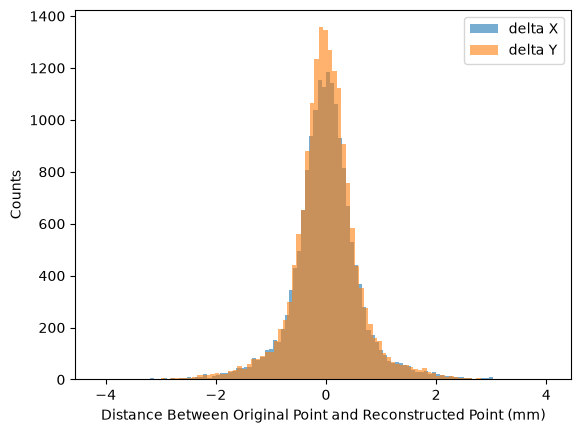

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9967 to 33.998
Y coordinate range: -33.999 to 33.9999
Average XGBoost Delta X (mm): 0.0015504871765659675
Median XGBoost Delta X (mm): -0.004061399762152897
Average XGBoost Delta Y (mm): -0.003287003778448868
Median XGBoost Delta Y (mm): 0.0008874362564085508


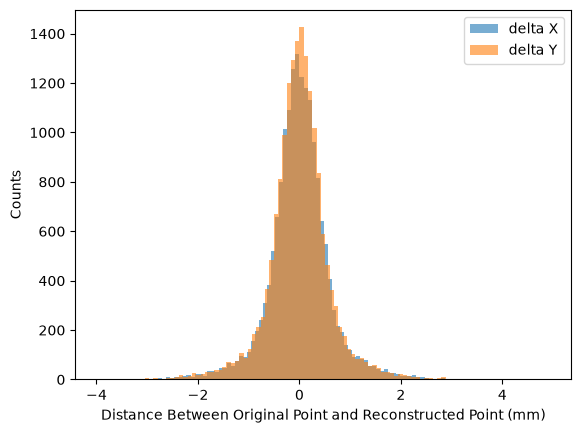

Number of events: 100000
X shape: (100000, 16)
y shape: (100000, 2)
X coordinate range: -33.9994 to 33.9998
Y coordinate range: -33.9982 to 33.9999
Average XGBoost Delta X (mm): -6.394793310884102e-05
Median XGBoost Delta X (mm): 0.0014966016844562384
Average XGBoost Delta Y (mm): 0.0010430303576401997
Median XGBoost Delta Y (mm): 0.0006480859279629847


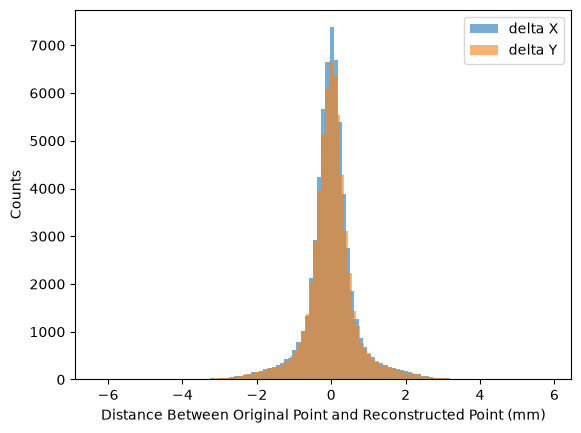

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9973 to 33.9983
Y coordinate range: -33.9989 to 33.9948
Average XGBoost Delta X (mm): 0.0020778395657097535
Median XGBoost Delta X (mm): -0.0017700231116486356
Average XGBoost Delta Y (mm): 0.0023808913331422616
Median XGBoost Delta Y (mm): -0.0011517417907722215


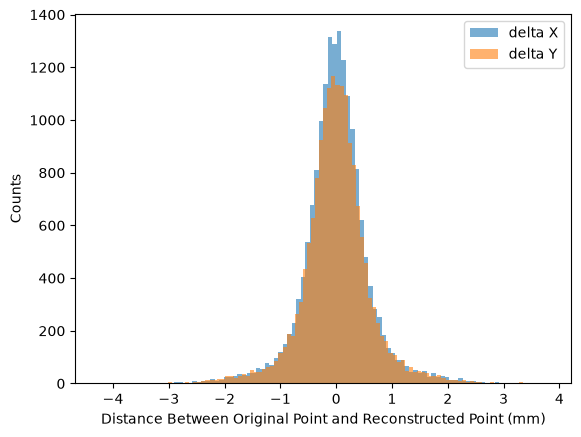

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9985 to 33.9957
Y coordinate range: -33.9968 to 33.9968
Average XGBoost Delta X (mm): -0.0006417301778223527
Median XGBoost Delta X (mm): 0.0033843978881853195
Average XGBoost Delta Y (mm): -0.0035226612339146275
Median XGBoost Delta Y (mm): -0.0032723373413087765


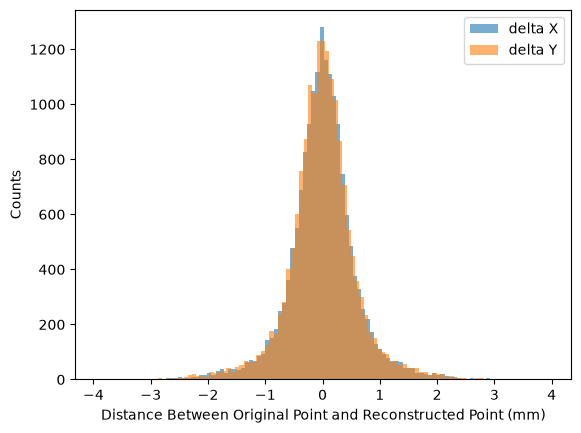

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9997 to 33.9998
Y coordinate range: -33.9981 to 33.9999
Average XGBoost Delta X (mm): 0.003967137270685809
Median XGBoost Delta X (mm): 0.0025157820129392975
Average XGBoost Delta Y (mm): -0.002587196745477414
Median XGBoost Delta Y (mm): -0.0016126788711551513


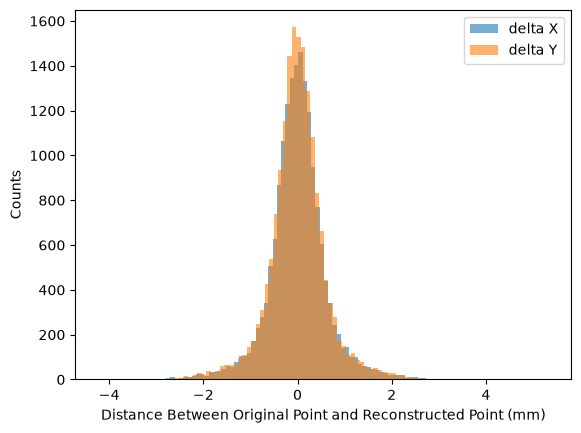

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9967 to 33.9993
Y coordinate range: -33.9892 to 33.999
Average XGBoost Delta X (mm): -0.0006224081218692894
Median XGBoost Delta X (mm): 0.001162699508666338
Average XGBoost Delta Y (mm): -0.0026046545176515454
Median XGBoost Delta Y (mm): -9.537124633887152e-05


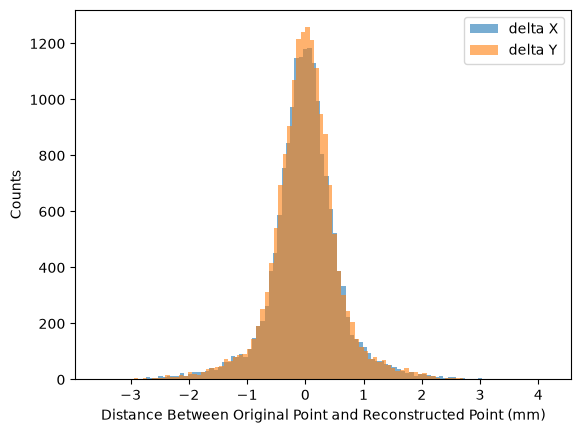

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9988 to 33.9957
Y coordinate range: -33.9898 to 33.9964
Average XGBoost Delta X (mm): -0.0011536301773695478
Median XGBoost Delta X (mm): 0.0013497948455816157
Average XGBoost Delta Y (mm): 0.002566125009734051
Median XGBoost Delta Y (mm): -0.0014848580741882763


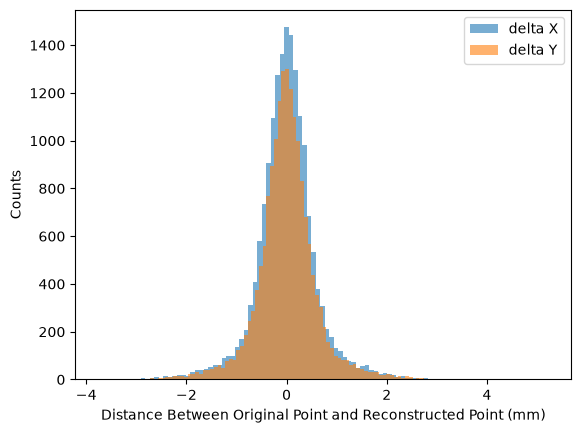

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9939 to 33.9976
Y coordinate range: -33.9962 to 33.9895
Average XGBoost Delta X (mm): 0.0033188482707674507
Median XGBoost Delta X (mm): 0.000590212326048686
Average XGBoost Delta Y (mm): 0.0021551296781975415
Median XGBoost Delta Y (mm): 0.006577321243286061


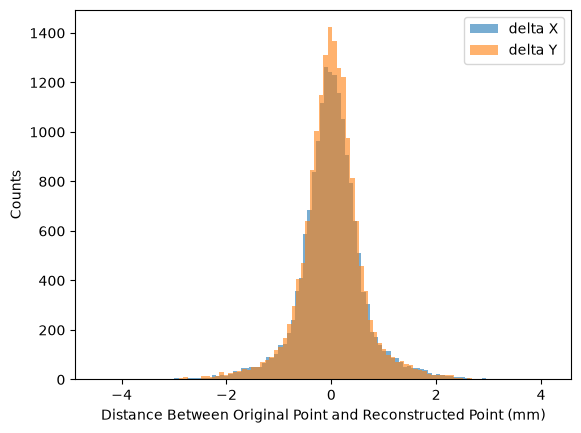

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9991 to 33.9929
Y coordinate range: -33.9979 to 33.999
Average XGBoost Delta X (mm): 0.0018748948574257849
Median XGBoost Delta X (mm): 0.002213135681152323
Average XGBoost Delta Y (mm): -0.0004584232651161365
Median XGBoost Delta Y (mm): -0.0017885223426821542


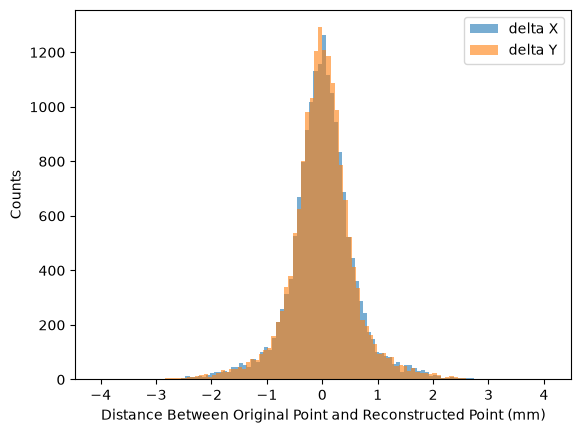

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9984 to 33.9939
Y coordinate range: -33.9982 to 33.9968
Average XGBoost Delta X (mm): 0.0020578590236451136
Median XGBoost Delta X (mm): -0.0002633075714115385
Average XGBoost Delta Y (mm): 0.0004517320253019458
Median XGBoost Delta Y (mm): 0.0011265064239509865


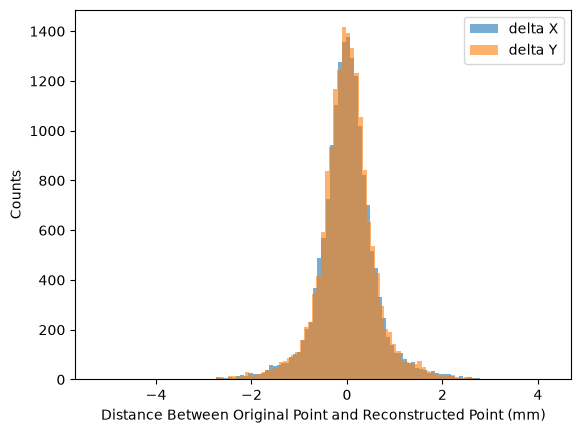

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9978 to 33.9999
Y coordinate range: -33.9978 to 33.9998
Average XGBoost Delta X (mm): -0.0010394564314553385
Median XGBoost Delta X (mm): -0.0008394481658938495
Average XGBoost Delta Y (mm): -0.0025740269169349564
Median XGBoost Delta Y (mm): -0.0010490786743167476


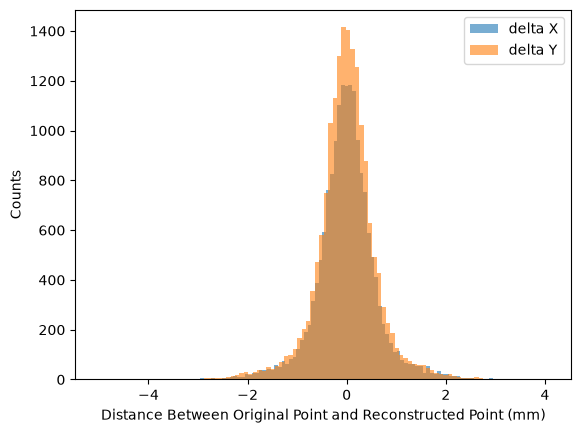

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.996 to 33.9983
Y coordinate range: -33.9992 to 33.9995
Average XGBoost Delta X (mm): 0.0008694396568358812
Median XGBoost Delta X (mm): -0.0018923406982418473
Average XGBoost Delta Y (mm): 0.0031095614629080585
Median XGBoost Delta Y (mm): 0.0023671066284180198


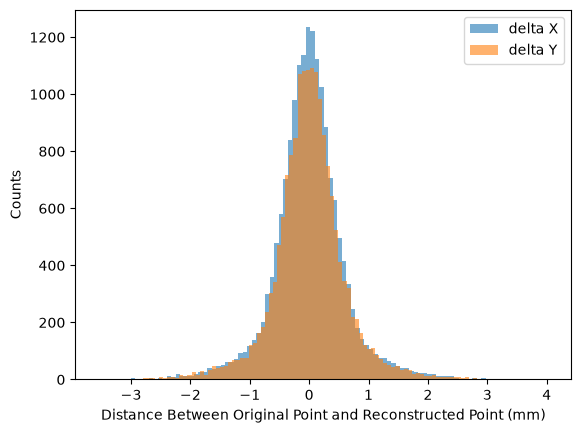

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.999 to 33.999
Y coordinate range: -33.9982 to 33.9999
Average XGBoost Delta X (mm): 0.0016878185372606338
Median XGBoost Delta X (mm): 0.0015539264640804906
Average XGBoost Delta Y (mm): 0.003581919815392631
Median XGBoost Delta Y (mm): -0.0007908552837373019


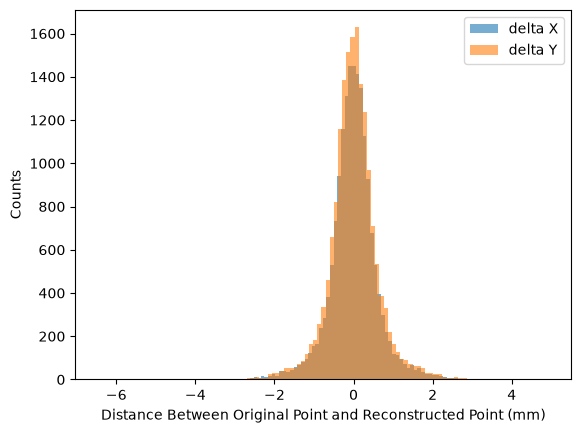

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9976 to 33.994
Y coordinate range: -33.9998 to 33.9988
Average XGBoost Delta X (mm): 0.004195731520383337
Median XGBoost Delta X (mm): 0.004818574943543371
Average XGBoost Delta Y (mm): 0.0005458923085804283
Median XGBoost Delta Y (mm): 0.002593775405883473


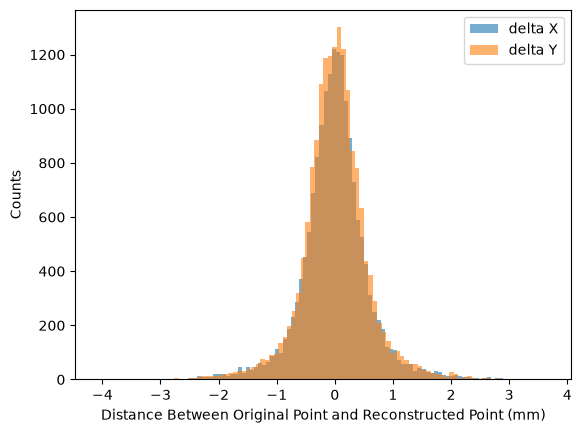

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9989 to 33.9988
Y coordinate range: -33.999 to 33.9959
Average XGBoost Delta X (mm): -0.0008290385438387775
Median XGBoost Delta X (mm): 0.0017340226364134497
Average XGBoost Delta Y (mm): -0.00014302204464221934
Median XGBoost Delta Y (mm): 0.0037108176803586877


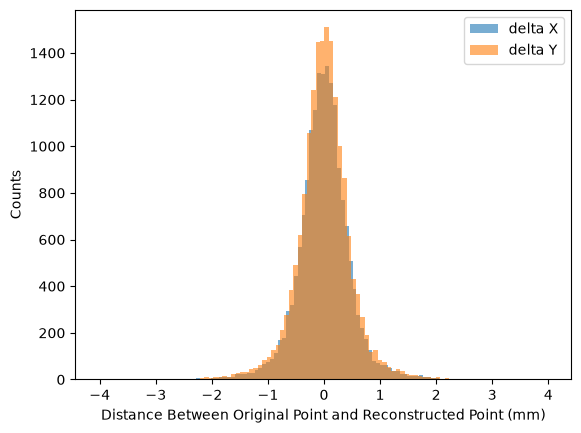

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9962 to 33.9993
Y coordinate range: -33.9855 to 33.9986
Average XGBoost Delta X (mm): 0.00029093504788398815
Median XGBoost Delta X (mm): 0.0005584970855714725
Average XGBoost Delta Y (mm): -0.0021219154430618
Median XGBoost Delta Y (mm): -0.00043789672851523524


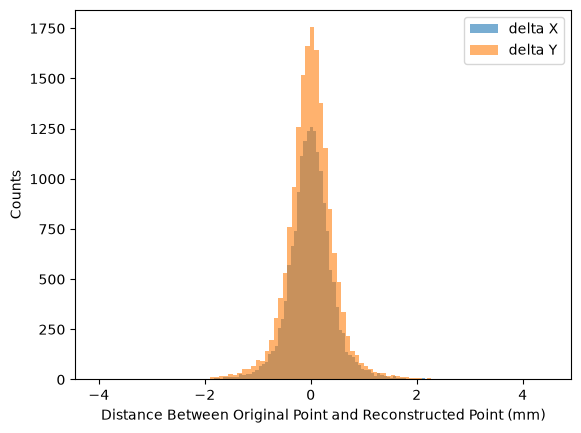

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9987 to 33.9998
Y coordinate range: -33.9984 to 33.9989
Average XGBoost Delta X (mm): 0.0007256459981467251
Median XGBoost Delta X (mm): 0.0010866809844969818
Average XGBoost Delta Y (mm): 0.0009940107893168836
Median XGBoost Delta Y (mm): -0.0008982727050785254


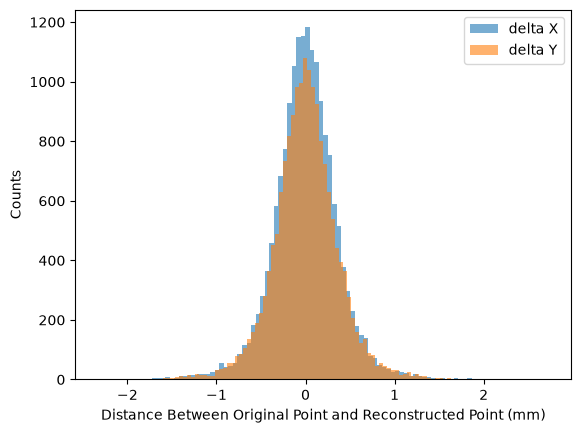

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -34.0 to 33.999
Y coordinate range: -33.9998 to 33.9955
Average XGBoost Delta X (mm): -0.0003008825097193998
Median XGBoost Delta X (mm): -0.0017063364410404326
Average XGBoost Delta Y (mm): 0.0016300737103932747
Median XGBoost Delta Y (mm): 0.001322382354735304


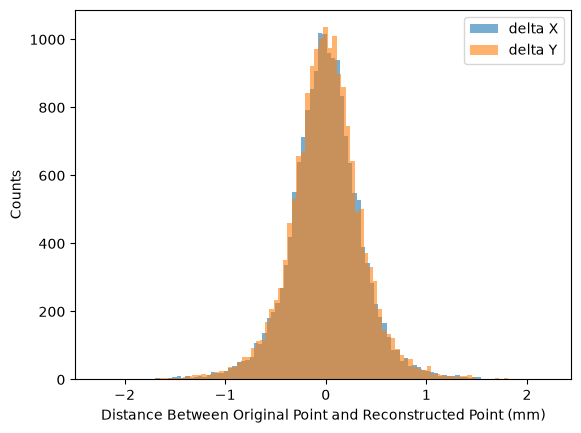

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9977 to 33.9996
Y coordinate range: -33.9919 to 33.9997
Average XGBoost Delta X (mm): 0.00010684702796324424
Median XGBoost Delta X (mm): 0.0015172554016128692
Average XGBoost Delta Y (mm): 0.0009050313020498104
Median XGBoost Delta Y (mm): 0.0004938320159910197


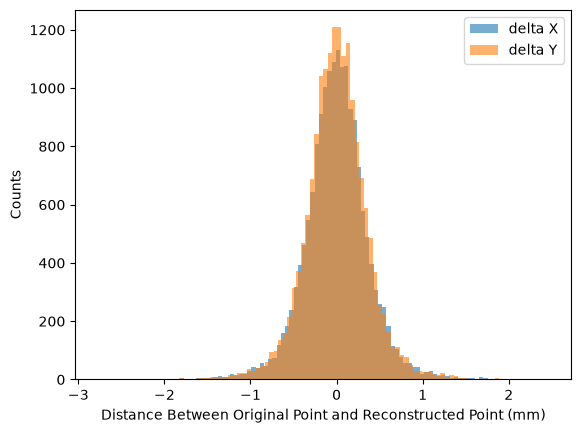

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9972 to 33.9997
Y coordinate range: -33.994 to 33.9968
Average XGBoost Delta X (mm): 0.0018104816102953232
Median XGBoost Delta X (mm): 0.0019604574966430198
Average XGBoost Delta Y (mm): 0.0009725883703355938
Median XGBoost Delta Y (mm): 0.001485276914596564


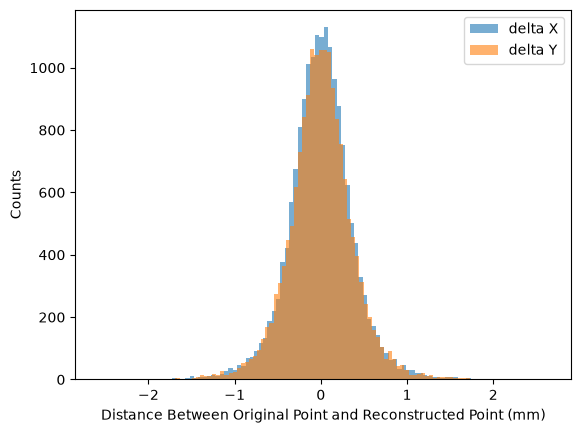

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9959 to 33.9958
Y coordinate range: -33.9971 to 33.9976
Average XGBoost Delta X (mm): 0.002246616973435161
Median XGBoost Delta X (mm): 0.002176938934325799
Average XGBoost Delta Y (mm): -0.0008221098920563212
Median XGBoost Delta Y (mm): -0.0026196258544921025


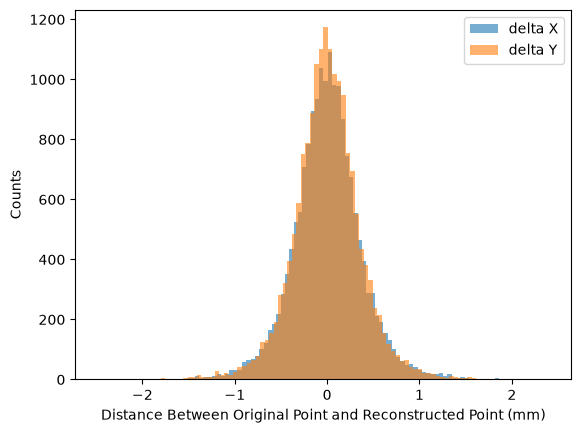

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9977 to 33.9953
Y coordinate range: -33.9936 to 33.9998
Average XGBoost Delta X (mm): -0.00140985551761817
Median XGBoost Delta X (mm): -0.00424106713294985
Average XGBoost Delta Y (mm): 0.002030797732242925
Median XGBoost Delta Y (mm): 0.0010779357910159493


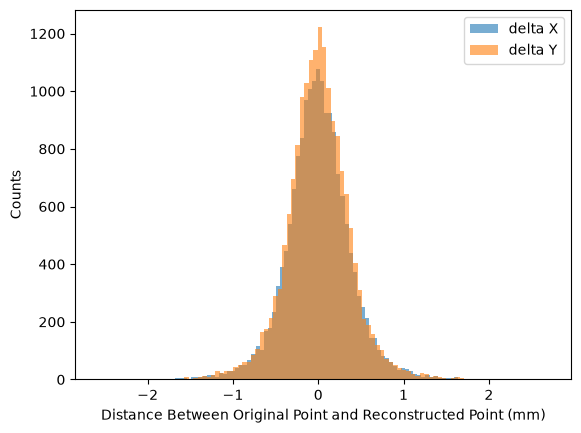

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9961 to 33.9983
Y coordinate range: -33.9981 to 33.9947
Average XGBoost Delta X (mm): -0.0027853423378476094
Median XGBoost Delta X (mm): -0.001852935028076888
Average XGBoost Delta Y (mm): -0.0011867540815479502
Median XGBoost Delta Y (mm): -0.0013628558349607252


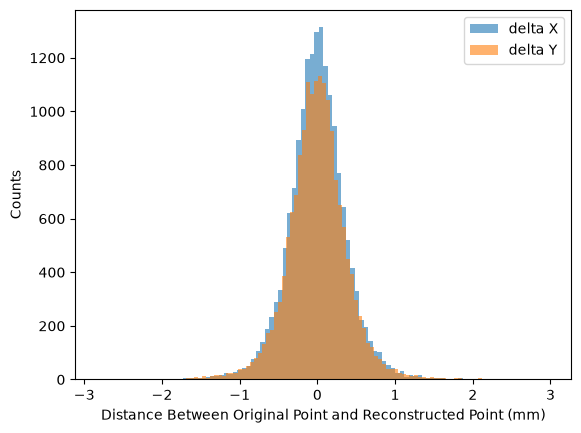

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9878 to 33.9959
Y coordinate range: -33.9992 to 33.9991
Average XGBoost Delta X (mm): -0.0009361432280660272
Median XGBoost Delta X (mm): -0.001853419494627688
Average XGBoost Delta Y (mm): -0.0006396683473916325
Median XGBoost Delta Y (mm): 0.0025351486206062618


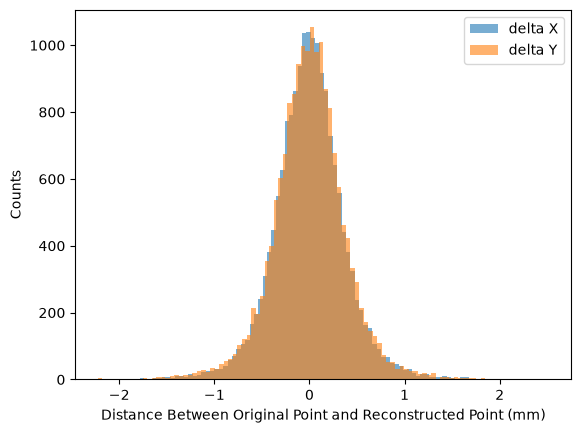

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9979 to 33.9948
Y coordinate range: -33.9934 to 33.993
Average XGBoost Delta X (mm): 0.0004933792272767745
Median XGBoost Delta X (mm): -0.0006600214385985197
Average XGBoost Delta Y (mm): 0.0009796486082473258
Median XGBoost Delta Y (mm): -0.0013033988952631907


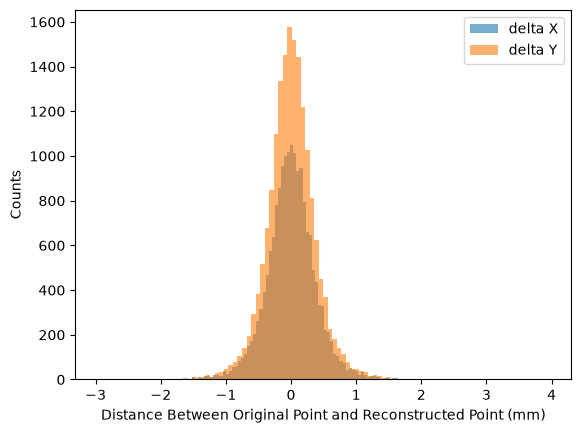

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9988 to 33.9996
Y coordinate range: -33.9967 to 33.998
Average XGBoost Delta X (mm): -0.0014935524244033941
Median XGBoost Delta X (mm): 0.0021484090232850583
Average XGBoost Delta Y (mm): 0.001161043269505622
Median XGBoost Delta Y (mm): 0.003285009050369097


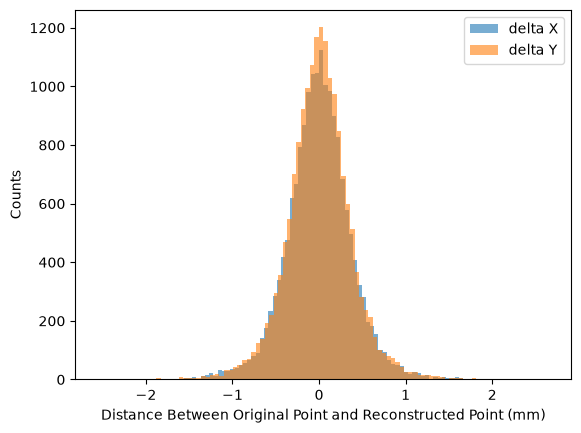

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9905 to 33.9934
Y coordinate range: -33.9881 to 33.9954
Average XGBoost Delta X (mm): 0.0014317141459665318
Median XGBoost Delta X (mm): 0.0016229704284672452
Average XGBoost Delta Y (mm): -0.0013250300125408608
Median XGBoost Delta Y (mm): -0.003456249504089553


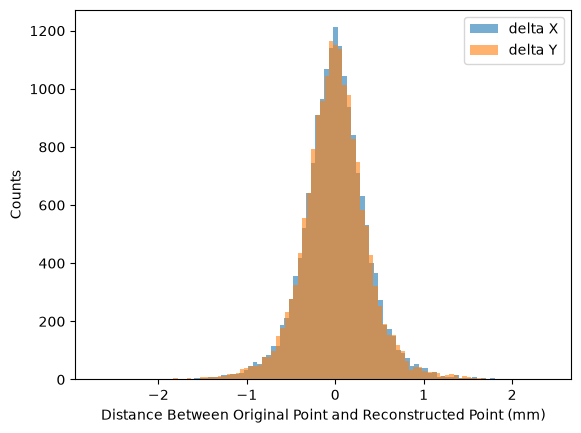

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9987 to 33.998
Y coordinate range: -33.9995 to 33.989
Average XGBoost Delta X (mm): 0.0013492832224231957
Median XGBoost Delta X (mm): -7.057176589979016e-05
Average XGBoost Delta Y (mm): 0.0016652380482503465
Median XGBoost Delta Y (mm): 0.003066117584228637


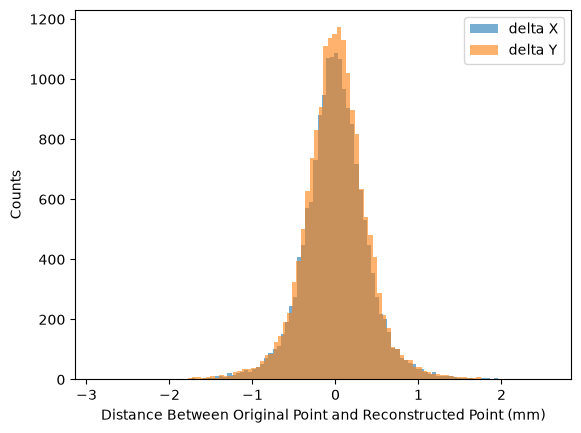

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9993 to 33.9984
Y coordinate range: -33.9976 to 33.9945
Average XGBoost Delta X (mm): -0.0013355814896721
Median XGBoost Delta X (mm): 0.00037328186035097324
Average XGBoost Delta Y (mm): 0.001760782733484258
Median XGBoost Delta Y (mm): 0.0022631844329827878


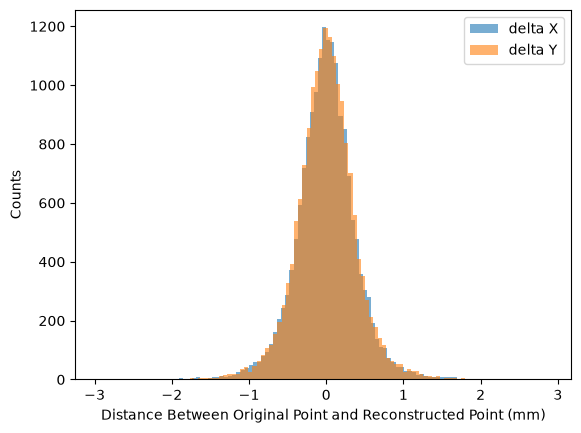

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9982 to 33.9994
Y coordinate range: -33.9998 to 33.9987
Average XGBoost Delta X (mm): 0.002119699779088486
Median XGBoost Delta X (mm): 0.0012551257514954914
Average XGBoost Delta Y (mm): -0.0027286906505143184
Median XGBoost Delta Y (mm): -0.004066663780213267


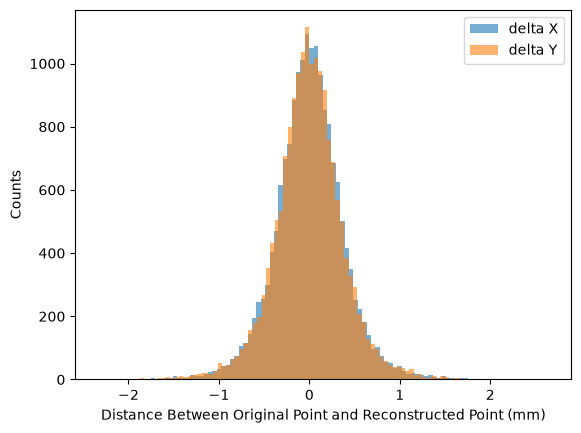

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9999 to 33.9994
Y coordinate range: -33.9928 to 33.9946
Average XGBoost Delta X (mm): 0.0009535129925716861
Median XGBoost Delta X (mm): -0.00026863777160663585
Average XGBoost Delta Y (mm): -0.0015393262055222224
Median XGBoost Delta Y (mm): 0.0003445236206051326


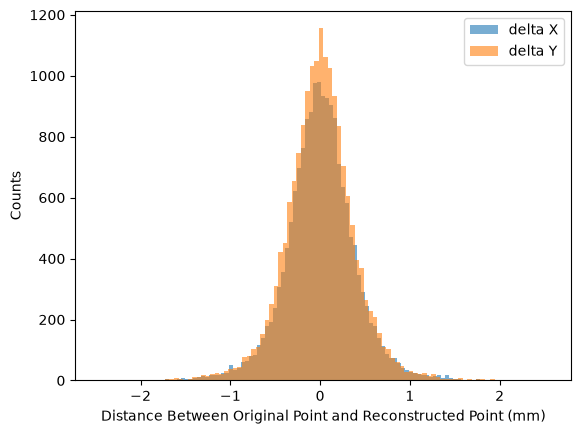

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9903 to 33.9981
Y coordinate range: -33.9983 to 33.9963
Average XGBoost Delta X (mm): -0.0020232550303312755
Median XGBoost Delta X (mm): 0.00037584468841532807
Average XGBoost Delta Y (mm): -0.002004212280308961
Median XGBoost Delta Y (mm): -0.0021697641754153396


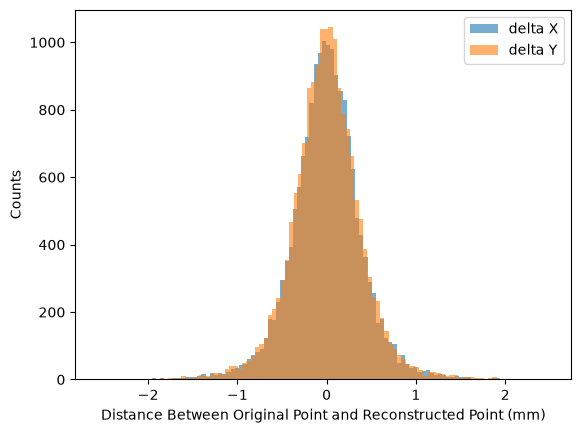

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9986 to 33.9986
Y coordinate range: -34.0 to 33.999
Average XGBoost Delta X (mm): 0.0015058152003851063
Median XGBoost Delta X (mm): 0.0036920922851562676
Average XGBoost Delta Y (mm): 0.0023157032199663864
Median XGBoost Delta Y (mm): -0.001232504272462622


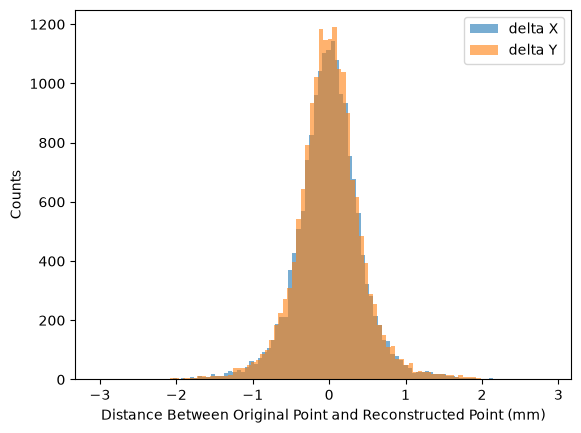

Number of events: 20000
X shape: (20000, 16)
y shape: (20000, 2)
X coordinate range: -33.9989 to 33.9831
Y coordinate range: -33.9999 to 33.9992
Average XGBoost Delta X (mm): -0.0022649486435514267
Median XGBoost Delta X (mm): -0.00111709442138732
Average XGBoost Delta Y (mm): -0.002391502577073171
Median XGBoost Delta Y (mm): -0.002954594055175952


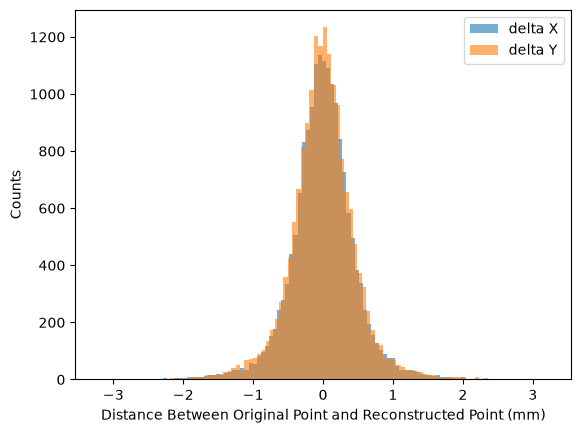

In [3]:
numbers = [3.05, 4.05, 5.05, 6.05, 7.05, 8.05, 9.05, 10.05, 11.05, 12.05, 13.05, 14.05, 14.3, 14.55, 14.8, 15.05, 15.3, 15.55, 15.8, 16.05, 16.3, 16.55, 16.8, 17.05, 17.3, 17.55, 17.8, 18.05, 18.3, 18.55, 18.8, 19.05, 20.05, 25.05, 40.05]

for q in numbers:
    file_path = os.path.join('/Users/judyz/Desktop/PET-4x4/build',f'{q}mm',f'{q}mm.csv')

    file = open(file_path)
    csvreader = csv.reader(file)

    original_X = []
    original_y = []

    line_count = 0

    for row in csvreader:
        if line_count >= 1:
            original_X.append([int(i) for i in row[1:17]])
            original_y.append([float(row[17]),float(row[18])])
        line_count += 1

    file.close()

    X = np.array(original_X)
    y = np.array(original_y)

    print("Number of events:", len(X))
    print("X shape:", X.shape)
    print("y shape:", y.shape)
    print("X coordinate range:",np.min(y[:, 0]),"to",np.max(y[:, 0]))
    print("Y coordinate range:",np.min(y[:, 1]),"to",np.max(y[:, 1]))

    XGBoost_distances = np.zeros((331, 331, 2))

    scaler = StandardScaler()

    for k in range(10):

        X_XGBoost = scaler.fit_transform(X)
        X_train, X_val, y_train, y_val = train_test_split(X_XGBoost,y,test_size=0.3)

        model = xgb.XGBRegressor()
        model.fit(X_train,y_train)

        yhat = model.predict(X_XGBoost)


        for i in range(len(X)):
            x_index = (165+round(y[i][0] * 5))
            y_index = (165-round(y[i][1] * 5))
            if (0 <= x_index < 331 and 0 <= y_index < 331):
                delta_x = (yhat[i][0] - y[i][0])
                XGBoost_distances[x_index,y_index,0]= (k / (k + 1)*XGBoost_distances[x_index, y_index,0] + 1 / (k + 1)*delta_x)
                delta_y = (yhat[i][1]-y[i][1])
                XGBoost_distances[x_index,y_index,1]= (k / (k + 1)*XGBoost_distances[x_index, y_index,1] + 1 / (k + 1)*delta_y)  

    delta_x_nonzero = XGBoost_distances[:, :, 0]
    delta_x_nonzero = delta_x_nonzero[delta_x_nonzero != 0]
    delta_y_nonzero = XGBoost_distances[:, :, 1]
    delta_y_nonzero = delta_y_nonzero[delta_y_nonzero != 0]

    print("Average XGBoost Delta X (mm): " + str(np.average(delta_x_nonzero)))     
    print("Median XGBoost Delta X (mm): " + str(np.median(delta_x_nonzero)))
    print("Average XGBoost Delta Y (mm): " + str(np.average(delta_y_nonzero)))     
    print("Median XGBoost Delta Y (mm): " + str(np.median(delta_y_nonzero)))

    plt.figure()
    plt.hist(delta_x_nonzero,bins=100,alpha=0.6,label='delta X')
    plt.hist(delta_y_nonzero,bins=100,alpha=0.6,label='delta Y')
    plt.xlabel('Distance Between Original Point and Reconstructed Point (mm)')
    plt.ylabel('Counts')
    plt.legend(loc='upper right')
    plt.show()

    XGBoost_distances_all_data.append(XGBoost_distances)

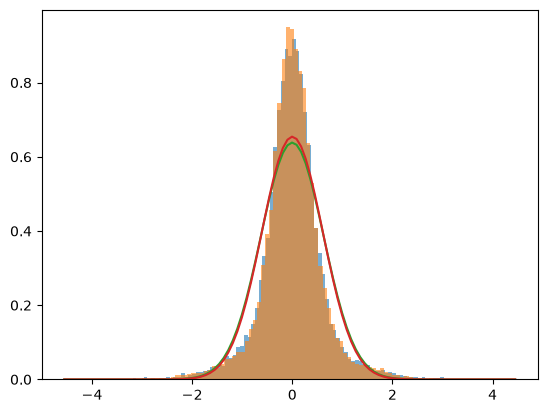

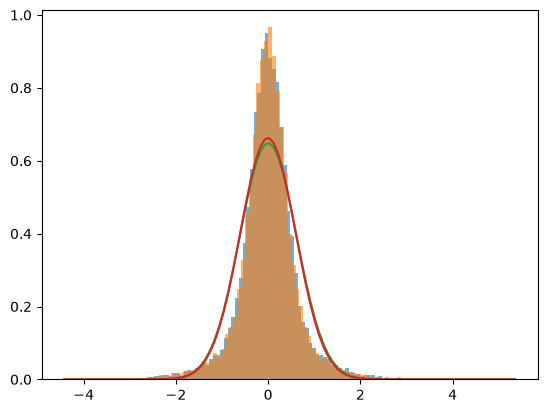

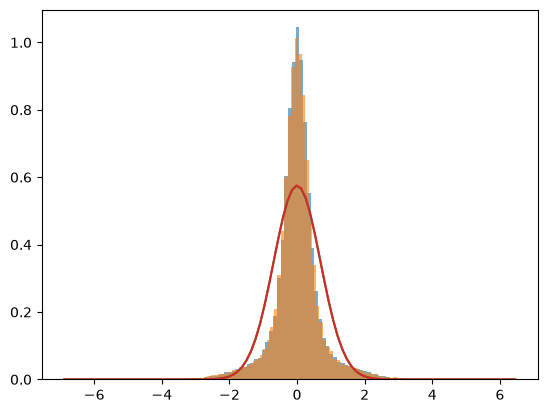

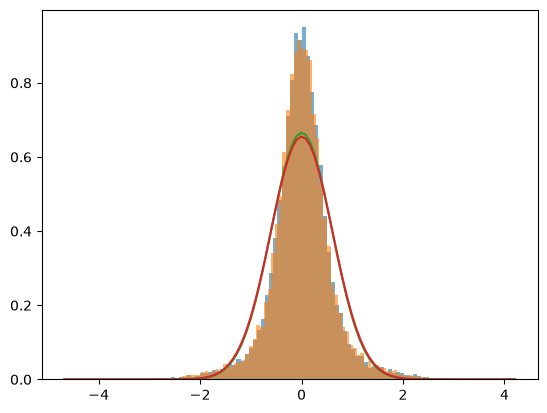

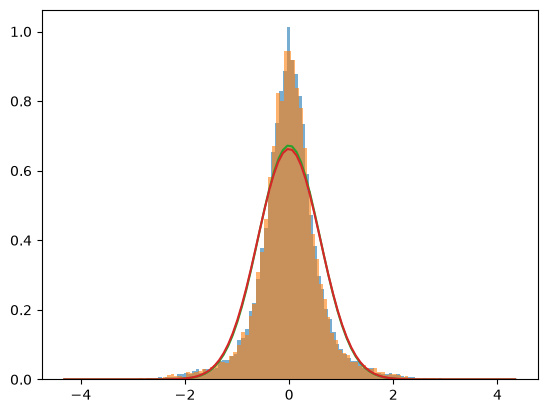

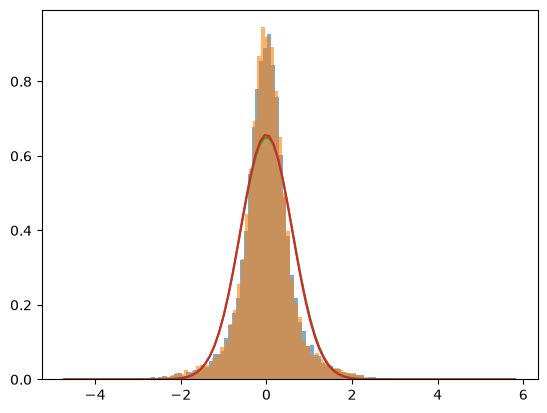

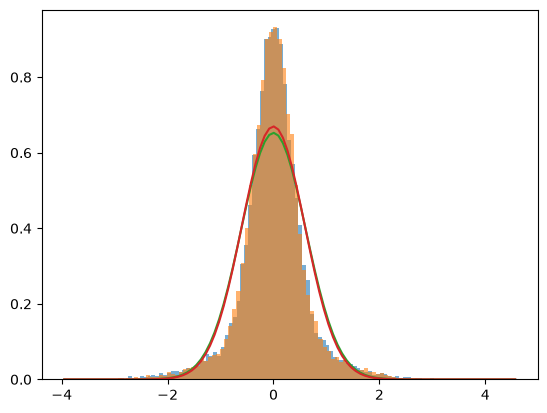

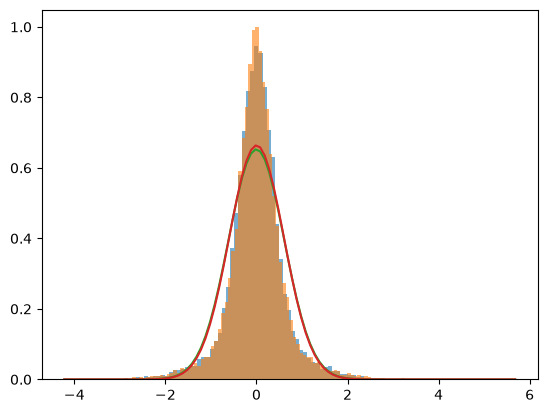

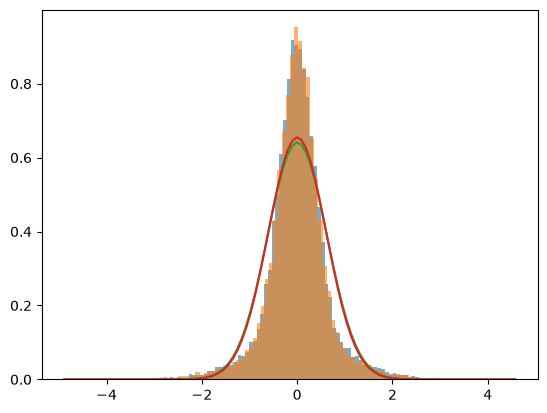

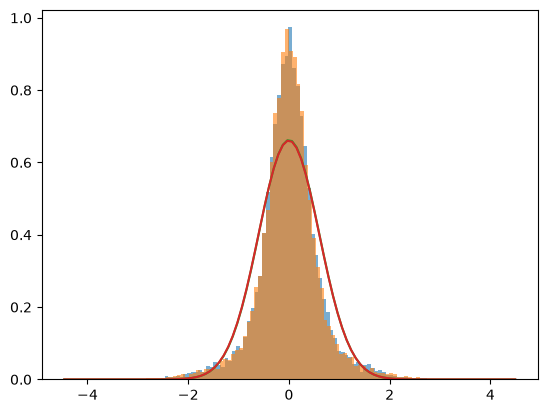

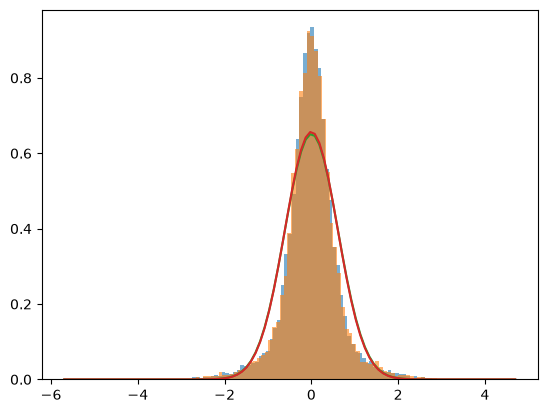

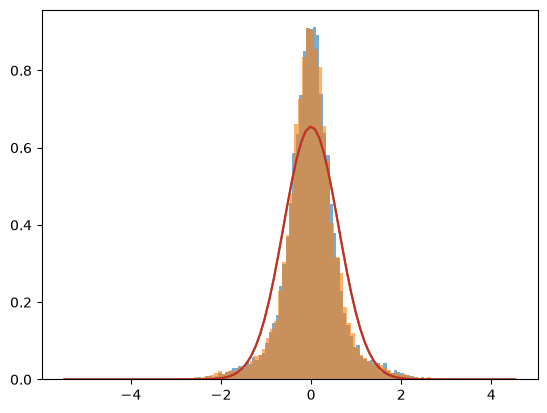

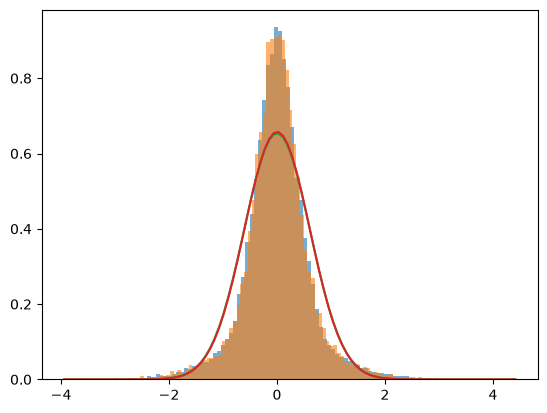

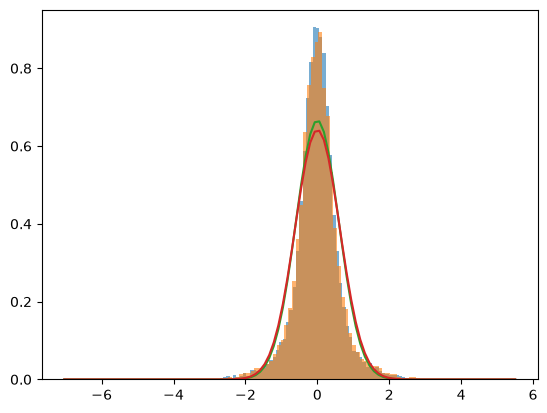

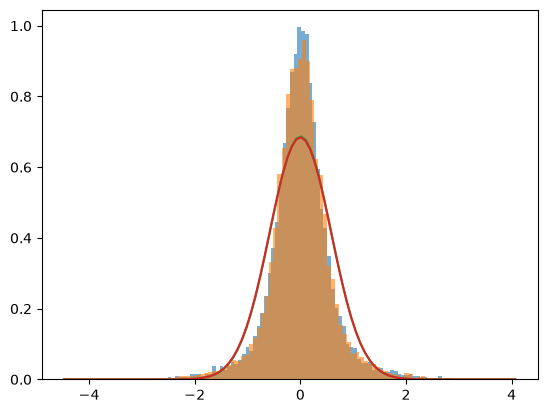

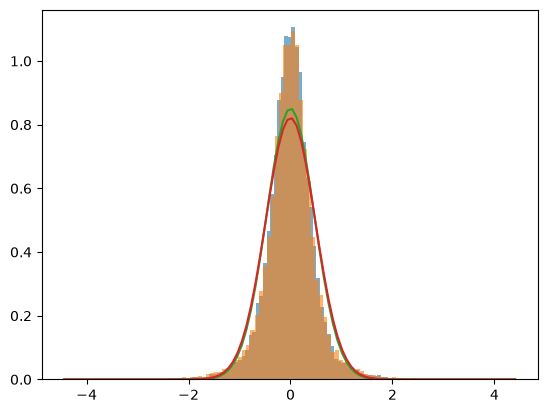

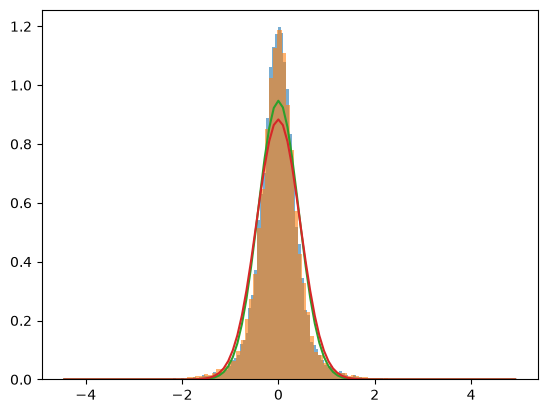

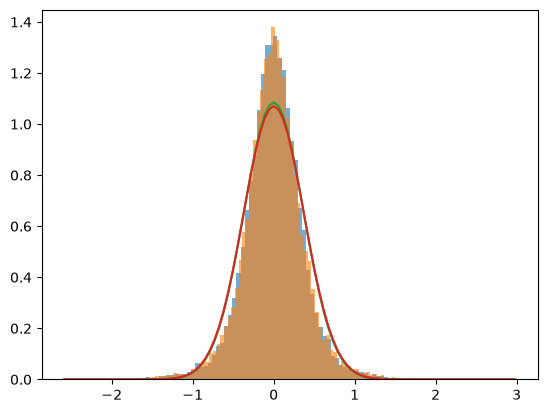

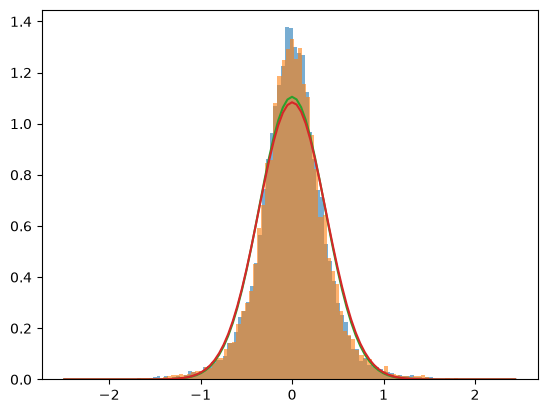

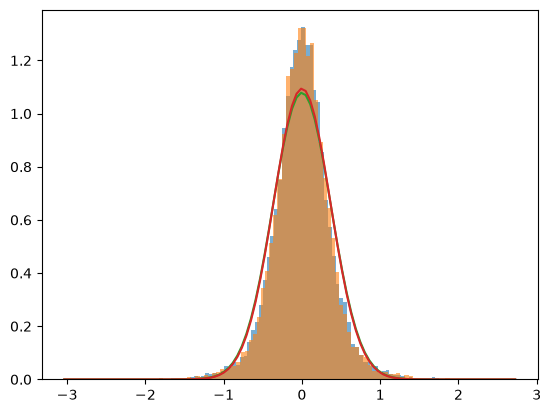

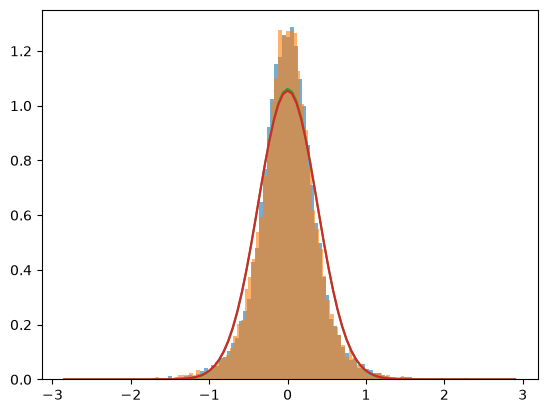

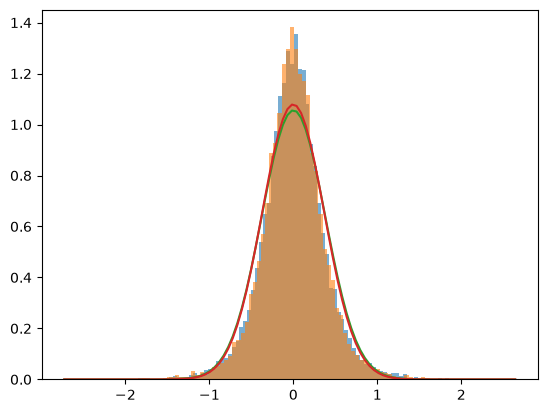

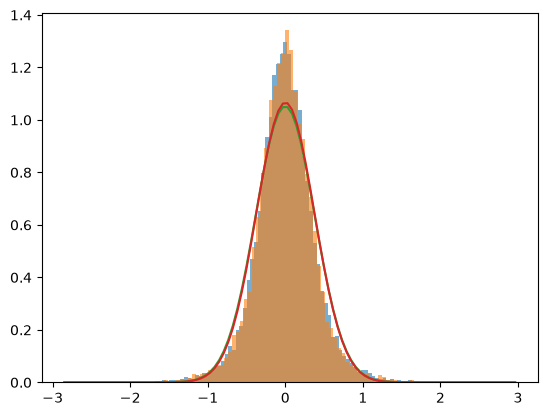

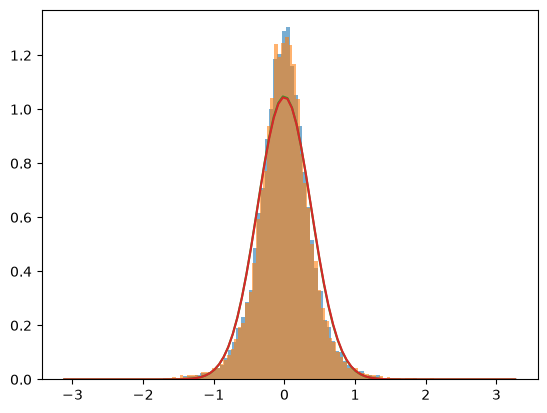

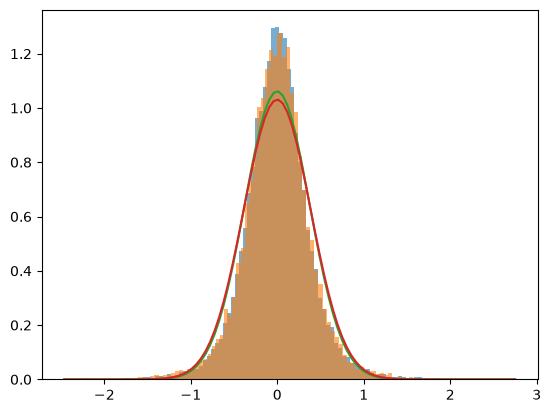

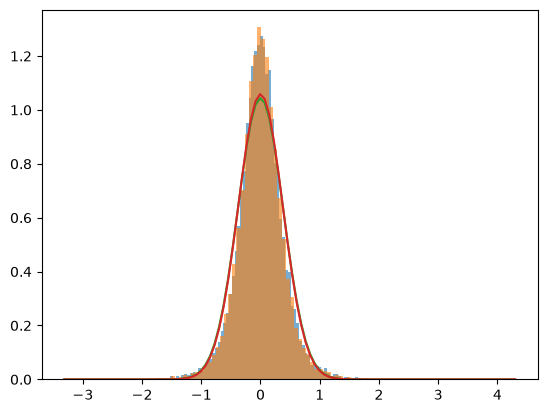

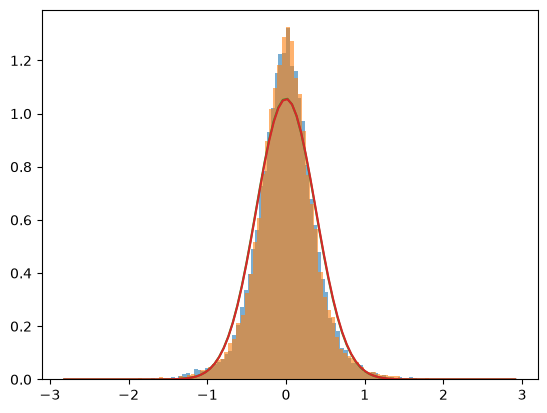

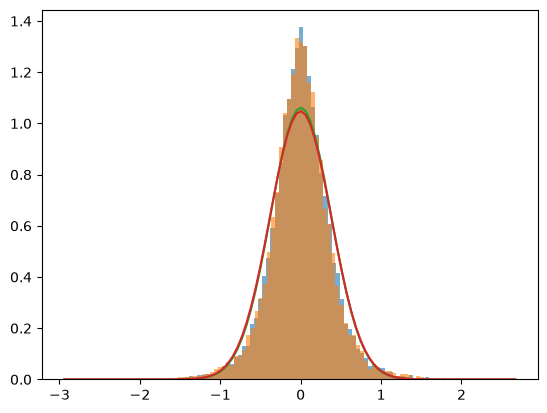

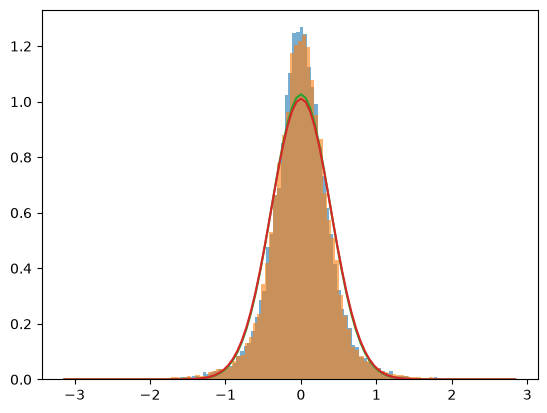

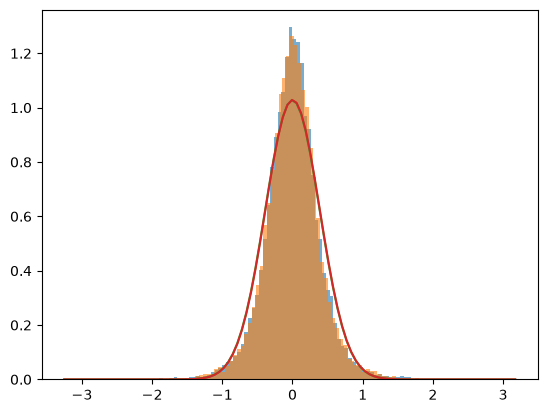

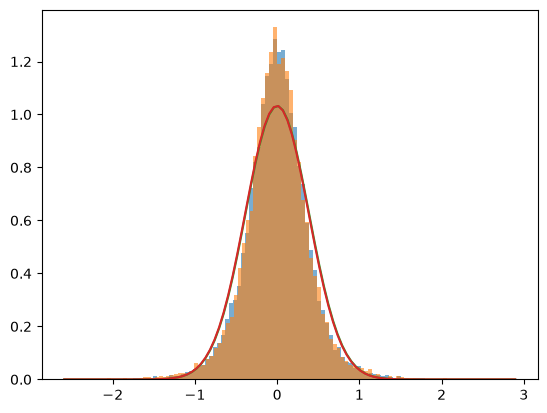

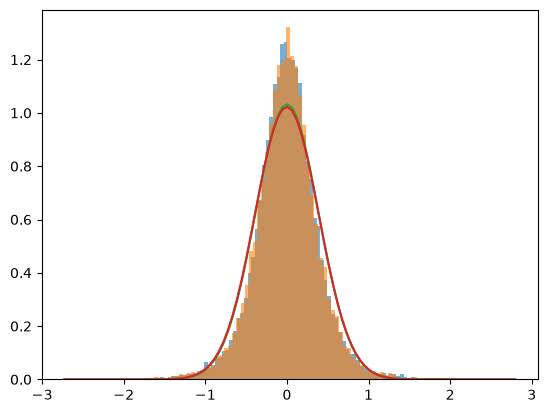

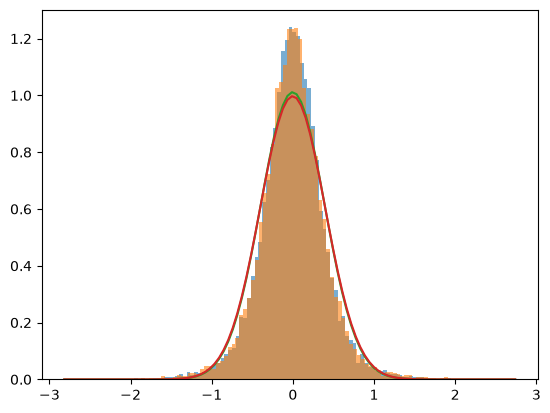

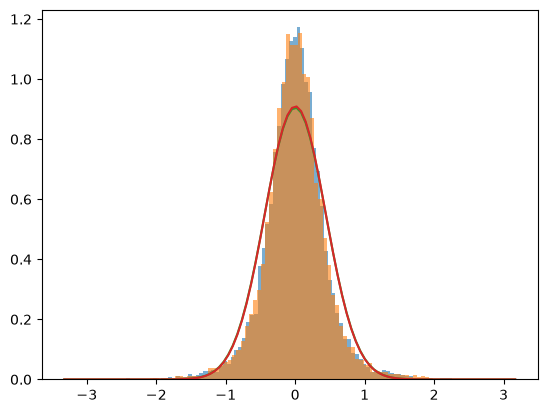

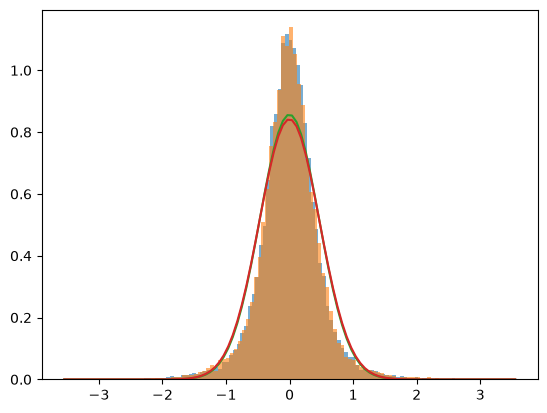

In [4]:
standard_deviations = []
means = []


for element in XGBoost_distances_all_data:

    delta_x = element[:, :, 0]
    delta_x = delta_x[delta_x != 0]

    delta_y = element[:, :, 1]
    delta_y = delta_y[delta_y != 0]

    meanx,stdx=norm.fit(delta_x)
    meany,stdy=norm.fit(delta_y)

    standard_deviations.append([stdx, stdy])
    means.append([meanx, meany])

    plt.hist(delta_x,bins=100,alpha=0.6,label='delta X',density=True)
    plt.hist(delta_y,bins=100,alpha=0.6,label='delta Y',density=True)

    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    xy = norm.pdf(x, meanx, stdx)
    yy = norm.pdf(x, meany, stdy)

    plt.plot(x, xy)
    plt.plot(x, yy)
    plt.show()

In [5]:

print([standard_deviations[9][0]*2.355, standard_deviations[9][1]*2.355])
print([standard_deviations[9][0],standard_deviations[9][1]])

XGBoost_distances_all_data_np = np.array(XGBoost_distances_all_data)

np.savetxt('XGBoost_distances_delta.csv',XGBoost_distances_all_data_np.reshape(XGBoost_distances_all_data_np.shape[0],-1    
    )
)

print(np.array(XGBoost_distances_all_data).shape)
print(np.array(XGBoost_distances_all_data).size)

[np.float64(1.4182115417069936), np.float64(1.4218088512593605)]
[np.float64(0.6022129688777043), np.float64(0.6037404888574779)]
(35, 331, 331, 2)
7669270
